# CSE570 – Machine Learning with Python
## Unit II Lab: Exploratory Data Analysis and Feature Engineering

<div style="background-color:#e8f4fd; padding:14px; border-left:6px solid #1976d2;">
<b>Learning goal:</b> Perform a complete EDA and feature-engineering workflow on a realistic classification dataset containing missing values, outliers, categorical variables, correlated features, and class imbalance.
</div>

**Dataset:** `CSE570_Unit2_Customer_Churn_Dataset.csv`

## 0. Libraries

This notebook uses common data-science libraries. `imbalanced-learn` is optional and is only required for the SMOTE demonstration.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)
from sklearn.utils import resample

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load the Dataset

The dataset intentionally contains imperfections so that we can practice realistic data preparation.

In [2]:
DATA_PATH = "CSE570_Unit2_Customer_Churn_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1208, 14)


,CustomerID,Age,Gender,TenureMonths,MonthlyCharges,TotalCharges,SupportCalls,SatisfactionScore,ContractType,PaymentMethod,InternetUsageGB,AnnualIncome,Region,Churn
0,CUST100000,27.0,Male,29,63.58,NaN,2,1,One Year,Net Banking,152.96,31172.97,South,0
1,CUST100001,36.0,Female,36,100.15,3496.65,3,4,One Year,Credit Card,118.13,67921.36,North,0
2,CUST100002,40.0,Male,14,77.08,1056.23,1,4,Month-to-Month,UPI,123.11,32261.85,East,0
3,CUST100003,23.0,Female,54,30.90,1533.91,1,4,One Year,Credit Card,105.23,93014.00,West,0
4,CUST100004,56.0,Male,55,59.27,3255.20,4,4,Month-to-Month,Debit Card,72.40,18000.00,East,0


## 2. Understand the Structure

Use `shape`, `info()`, `describe()`, and data types before making any preprocessing decision.

In [3]:
print("Rows, Columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Rows, Columns: (1208, 14)

Column names:
['CustomerID', 'Age', 'Gender', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportCalls', 'SatisfactionScore', 'ContractType', 'PaymentMethod', 'InternetUsageGB', 'AnnualIncome', 'Region', 'Churn']

Data types:


,dtype
CustomerID,object
Age,float64
Gender,object
TenureMonths,int64
MonthlyCharges,float64
TotalCharges,float64
SupportCalls,int64
SatisfactionScore,int64
ContractType,object
PaymentMethod,object



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1208 non-null   object 
 1   Age                1178 non-null   float64
 2   Gender             1190 non-null   object 
 3   TenureMonths       1208 non-null   int64  
 4   MonthlyCharges     1184 non-null   float64
 5   TotalCharges       1166 non-null   float64
 6   SupportCalls       1208 non-null   int64  
 7   SatisfactionScore  1208 non-null   int64  
 8   ContractType       1208 non-null   object 
 9   PaymentMethod      1184 non-null   object 
 10  InternetUsageGB    1176 non-null   float64
 11  AnnualIncome       1172 non-null   float64
 12  Region             1208 non-null   object 
 13  Churn              1208 non-null   int64  
dtypes: float64(5), int64(4), object(5)
memory usage: 132.3+ KB


In [4]:
print("Numerical summary:")
display(df.describe().T)

print("\nCategorical summary:")
display(df.describe(include="object").T)

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Age,1178.0,38.552632,11.280137,18.0,31.0000,39.000,46.0000,75.000000
TenureMonths,1208.0,26.208609,17.118899,1.0,13.0000,22.000,35.0000,72.000000
MonthlyCharges,1184.0,72.929267,25.656271,20.0,57.8900,71.820,86.0650,299.558842
TotalCharges,1166.0,1878.359297,1418.960246,20.0,884.5650,1504.950,2492.7550,10604.410000
SupportCalls,1208.0,2.014073,1.427265,0.0,1.0000,2.000,3.0000,7.000000
SatisfactionScore,1208.0,3.355960,0.996654,1.0,3.0000,3.000,4.0000,5.000000
InternetUsageGB,1176.0,83.196144,59.580689,9.3,47.1075,70.245,104.0425,952.569688
AnnualIncome,1172.0,54431.737415,28490.405532,18000.0,34595.7500,48161.240,67789.6800,276803.450000
Churn,1208.0,0.111755,0.315195,0.0,0.0000,0.000,0.0000,1.000000



Categorical summary:


,count,unique,top,freq
CustomerID,1208,1200,CUST100792,2
Gender,1190,3,Male,589
ContractType,1208,3,Month-to-Month,714
PaymentMethod,1184,4,UPI,438
Region,1208,4,North,334


## 3. Data Quality: Missing Values

We calculate both count and percentage. Percentage is more informative when datasets differ in size.

In [5]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().mean() * 100).round(2)
}).sort_values("Missing_Percent", ascending=False)

display(missing_summary)

,Missing_Count,Missing_Percent
TotalCharges,42,3.48
AnnualIncome,36,2.98
InternetUsageGB,32,2.65
Age,30,2.48
MonthlyCharges,24,1.99
PaymentMethod,24,1.99
Gender,18,1.49
CustomerID,0,0.00
TenureMonths,0,0.00
SupportCalls,0,0.00


## 4. Data Quality: Duplicate Rows

Duplicates should be investigated before deletion. Here they were intentionally inserted as exact duplicates.

In [6]:
duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

duplicate_examples = df[df.duplicated(keep=False)].sort_values("CustomerID")
display(duplicate_examples.head(12))

Number of exact duplicate rows: 8


,CustomerID,Age,Gender,TenureMonths,MonthlyCharges,TotalCharges,SupportCalls,SatisfactionScore,ContractType,PaymentMethod,InternetUsageGB,AnnualIncome,Region,Churn
224,CUST100224,46.0,Male,58,51.58,2958.65,3,3,Month-to-Month,Credit Card,55.89,68742.86,North,1
1205,CUST100224,46.0,Male,58,51.58,2958.65,3,3,Month-to-Month,Credit Card,55.89,68742.86,North,1
225,CUST100225,52.0,Female,14,93.56,1327.40,1,3,Month-to-Month,UPI,67.27,81503.65,West,1
1202,CUST100225,52.0,Female,14,93.56,1327.40,1,3,Month-to-Month,UPI,67.27,81503.65,West,1
275,CUST100275,43.0,Female,25,66.78,1813.98,2,1,Month-to-Month,Net Banking,NaN,31446.64,West,1
1200,CUST100275,43.0,Female,25,66.78,1813.98,2,1,Month-to-Month,Net Banking,NaN,31446.64,West,1
296,CUST100296,21.0,Female,12,61.83,816.76,2,3,Month-to-Month,Credit Card,31.63,80636.51,East,0
1207,CUST100296,21.0,Female,12,61.83,816.76,2,3,Month-to-Month,Credit Card,31.63,80636.51,East,0
787,CUST100787,47.0,Female,2,64.85,128.99,1,3,Month-to-Month,Net Banking,233.49,85948.51,North,0
1204,CUST100787,47.0,Female,2,64.85,128.99,1,3,Month-to-Month,Net Banking,233.49,85948.51,North,0


In [7]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1200, 14)


# 5. Univariate EDA

Univariate analysis studies one variable at a time.

We inspect:
- numerical distributions,
- categorical frequencies,
- skewness,
- possible outliers.

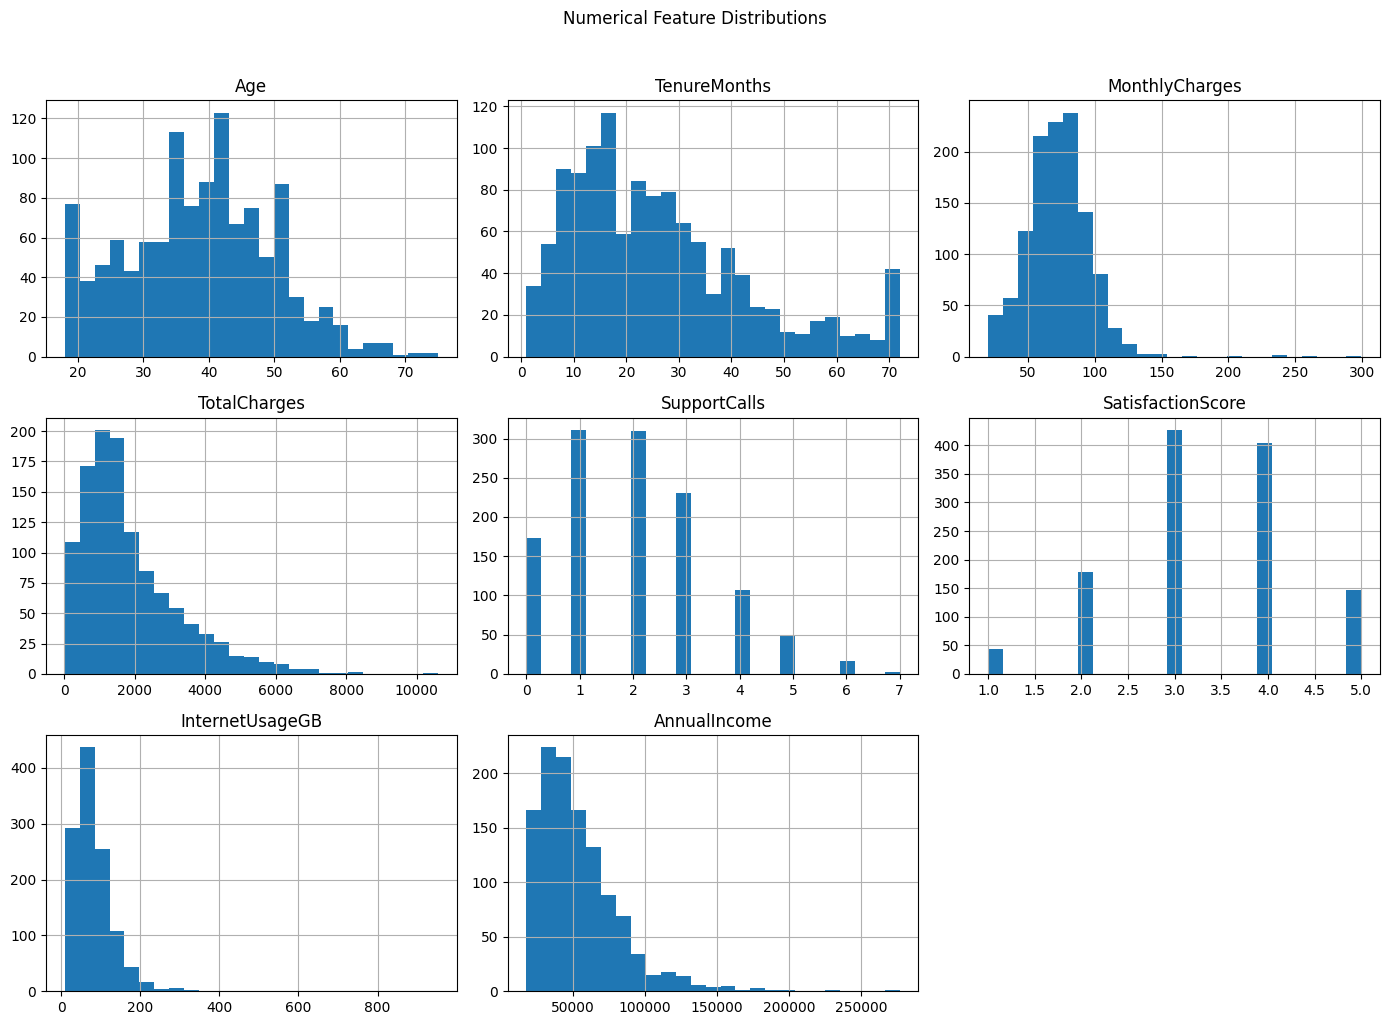

In [8]:
numeric_cols = [
    "Age", "TenureMonths", "MonthlyCharges", "TotalCharges",
    "SupportCalls", "SatisfactionScore", "InternetUsageGB", "AnnualIncome"
]

df[numeric_cols].hist(figsize=(14, 10), bins=25)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
skewness = df[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)
display(skewness.to_frame("Skewness"))

,Skewness
InternetUsageGB,4.718824
AnnualIncome,1.871390
MonthlyCharges,1.659369
TotalCharges,1.478828
TenureMonths,0.946406
SupportCalls,0.591502
Age,0.109808
SatisfactionScore,-0.244894


### Interpretation prompt

- Which variable has the highest positive skew?
- Which variables look approximately symmetric?
- Which variables may contain extreme observations?

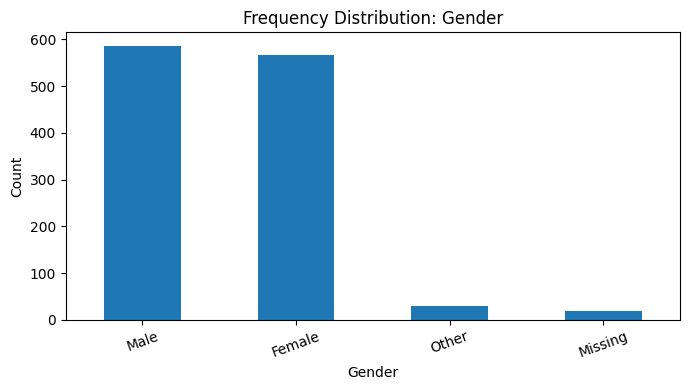

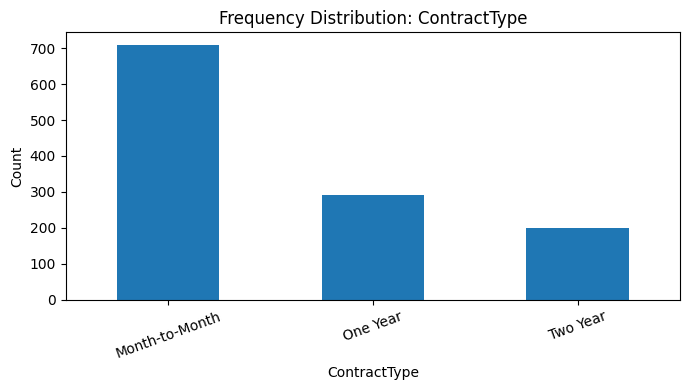

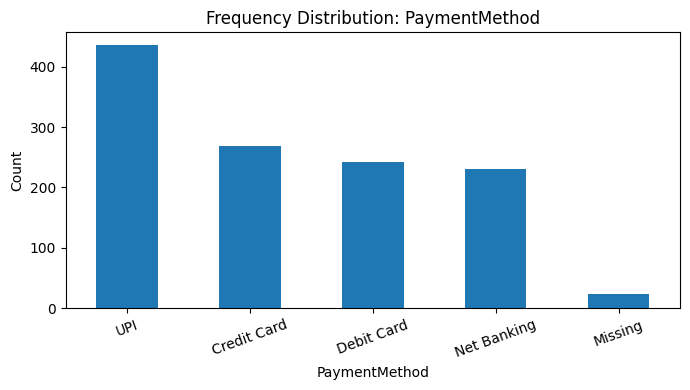

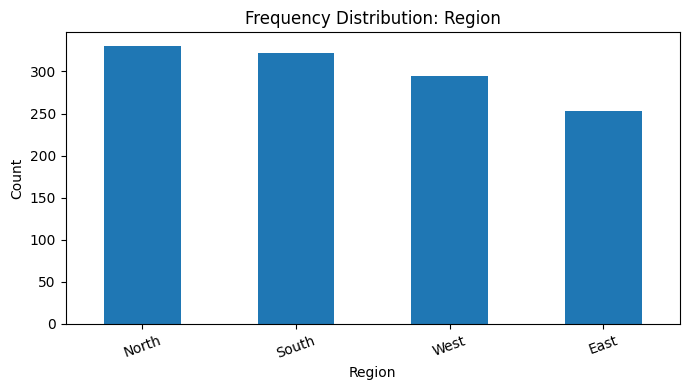

In [10]:
categorical_cols = ["Gender", "ContractType", "PaymentMethod", "Region"]

for col in categorical_cols:
    counts = df[col].fillna("Missing").value_counts()
    plt.figure(figsize=(7, 4))
    counts.plot(kind="bar")
    plt.title(f"Frequency Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# 6. Target Distribution and Class Imbalance

The target is `Churn`:
- `0` = retained
- `1` = churned

,Count,Percent
Churn,,
0,1068,89.0
1,132,11.0


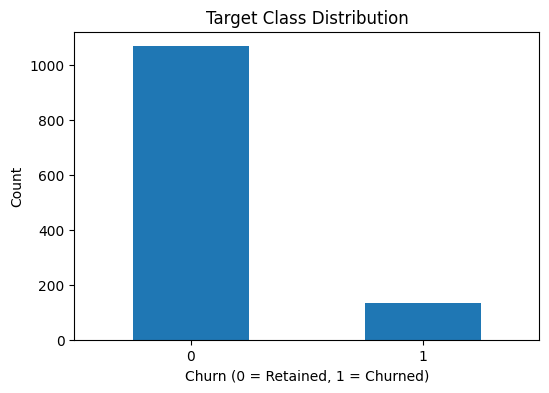

In [11]:
target_counts = df["Churn"].value_counts().sort_index()
target_pct = (df["Churn"].value_counts(normalize=True).sort_index() * 100).round(2)

display(pd.DataFrame({
    "Count": target_counts,
    "Percent": target_pct
}))

plt.figure(figsize=(6, 4))
df["Churn"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

<div style="background-color:#fff8e1; padding:12px; border-left:6px solid #ffb300;">
<b>Question:</b> If 85% of observations belonged to class 0, would 85% accuracy automatically represent a useful churn model? No. A model predicting only class 0 could obtain high accuracy while failing to identify any churners.
</div>

# 7. Bivariate Analysis

Bivariate analysis studies the relationship between two variables.

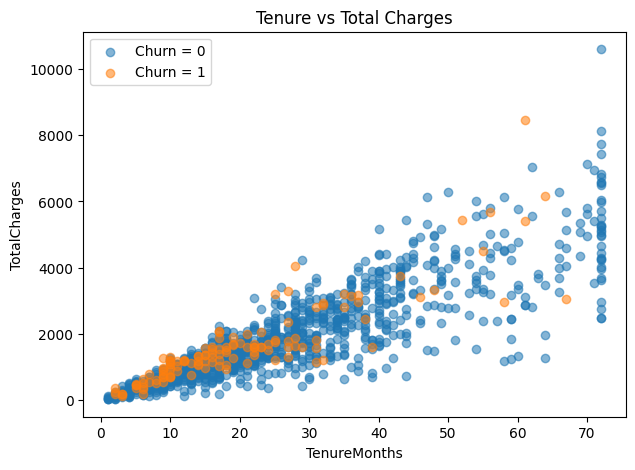

In [12]:
plt.figure(figsize=(7, 5))
for cls in sorted(df["Churn"].dropna().unique()):
    subset = df[df["Churn"] == cls]
    plt.scatter(
        subset["TenureMonths"],
        subset["TotalCharges"],
        alpha=0.55,
        label=f"Churn = {cls}"
    )
plt.title("Tenure vs Total Charges")
plt.xlabel("TenureMonths")
plt.ylabel("TotalCharges")
plt.legend()
plt.show()

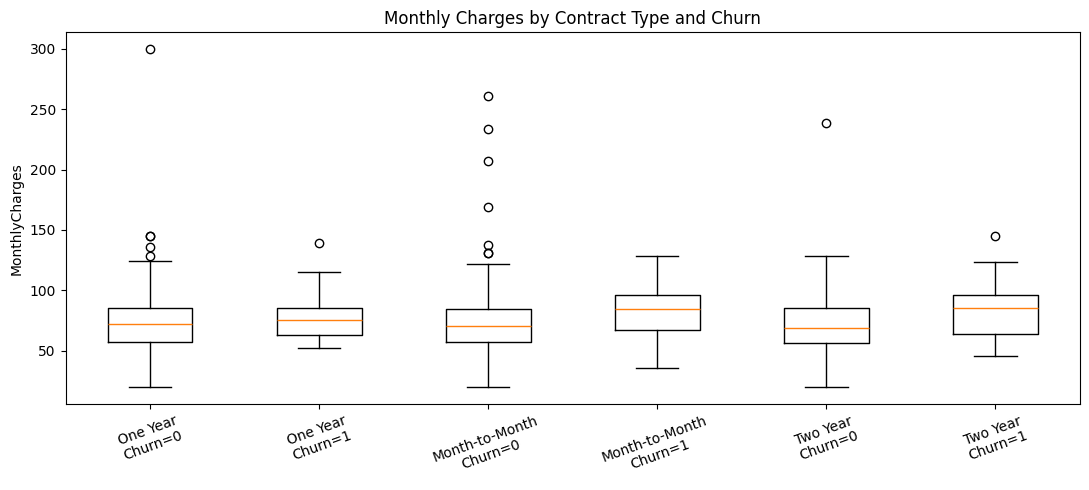

In [13]:
grouped_data = []
group_labels = []

for contract in df["ContractType"].dropna().unique():
    for cls in sorted(df["Churn"].dropna().unique()):
        values = df.loc[
            (df["ContractType"] == contract) & (df["Churn"] == cls),
            "MonthlyCharges"
        ].dropna()
        grouped_data.append(values)
        group_labels.append(f"{contract}\nChurn={cls}")

plt.figure(figsize=(11, 5))
plt.boxplot(grouped_data, tick_labels=group_labels)
plt.title("Monthly Charges by Contract Type and Churn")
plt.ylabel("MonthlyCharges")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [14]:
churn_by_contract = pd.crosstab(
    df["ContractType"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

display(churn_by_contract)

Churn,0,1
ContractType,,
Month-to-Month,86.32,13.68
One Year,92.47,7.53
Two Year,93.47,6.53


# 8. Correlation Analysis

Pearson correlation measures **linear** association among numerical variables.  
Spearman correlation measures **monotonic rank-based** association and is more robust to non-normality and some outliers.

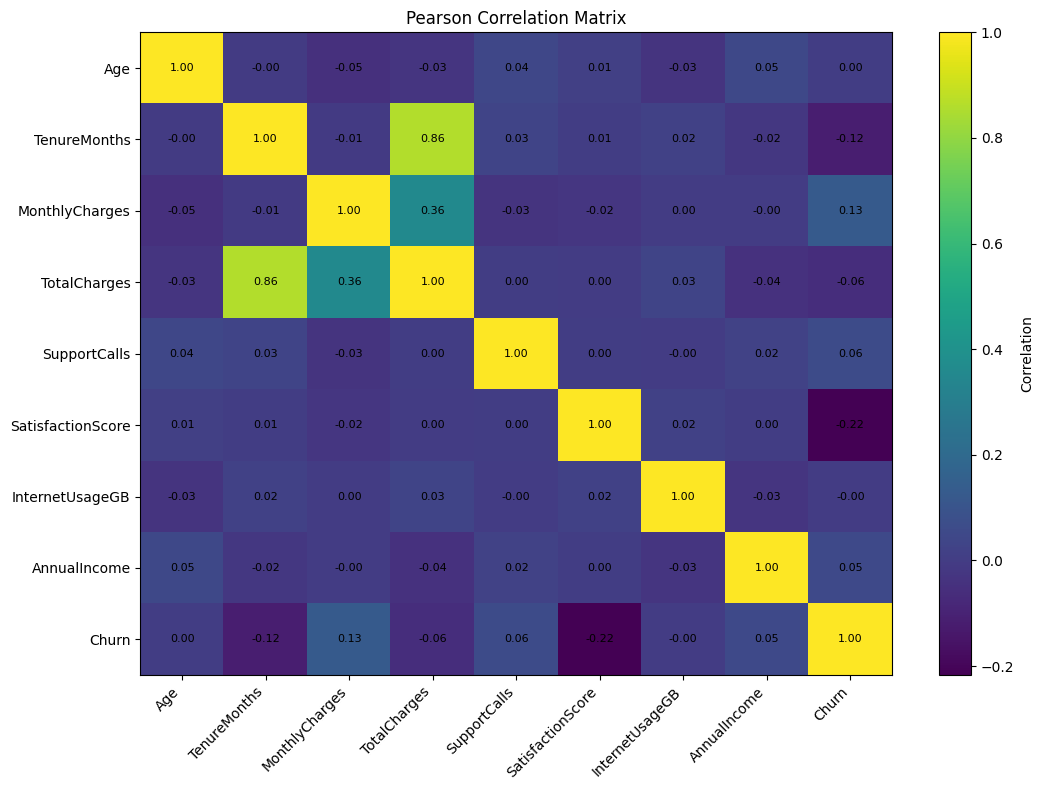

In [15]:
numeric_for_corr = df.select_dtypes(include="number")

pearson_corr = numeric_for_corr.corr(method="pearson")

plt.figure(figsize=(11, 8))
plt.imshow(pearson_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(pearson_corr.columns)), pearson_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(pearson_corr.index)), pearson_corr.index)

for i in range(len(pearson_corr.index)):
    for j in range(len(pearson_corr.columns)):
        plt.text(j, i, f"{pearson_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

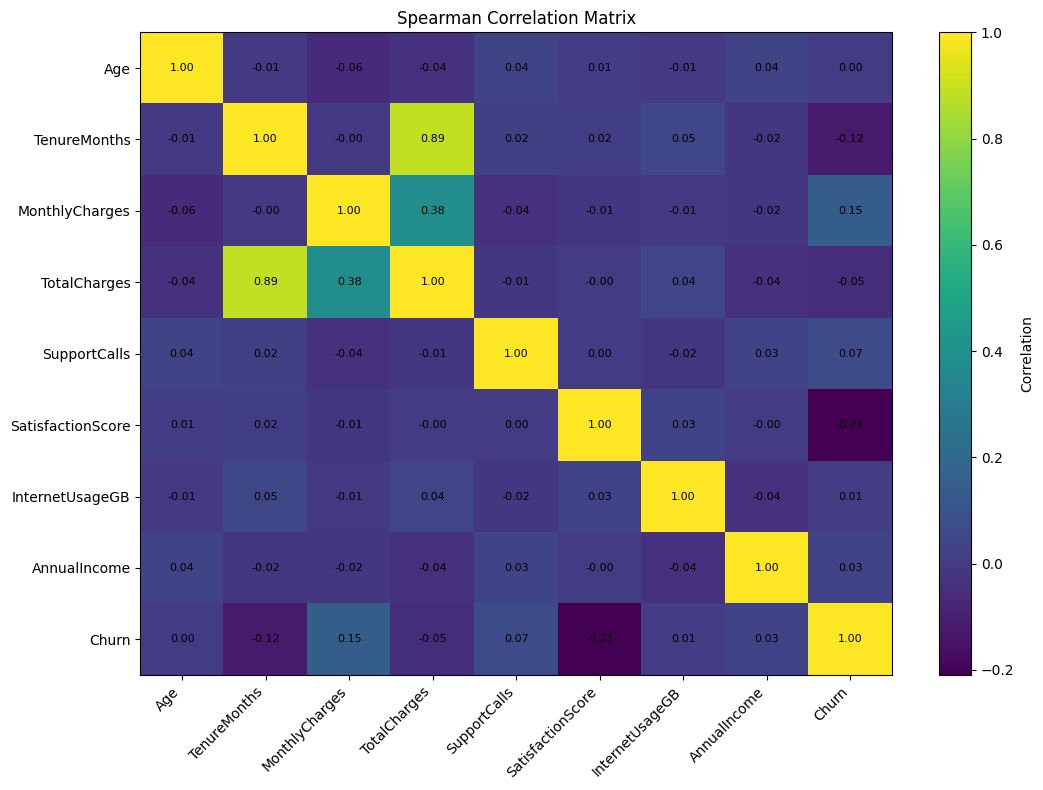

In [16]:
spearman_corr = numeric_for_corr.corr(method="spearman")

plt.figure(figsize=(11, 8))
plt.imshow(spearman_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(spearman_corr.columns)), spearman_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(spearman_corr.index)), spearman_corr.index)

for i in range(len(spearman_corr.index)):
    for j in range(len(spearman_corr.columns)):
        plt.text(j, i, f"{spearman_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

## 8.1 Find Highly Correlated Features

A high correlation does not automatically mean a feature must be removed. We use it as a diagnostic.

In [17]:
corr_abs = numeric_for_corr.corr().abs()

upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        value = upper.loc[row, col]
        if pd.notna(value) and value > 0.80:
            high_corr_pairs.append((row, col, round(value, 3)))

print("Pairs with |correlation| > 0.80:")
for pair in high_corr_pairs:
    print(pair)

Pairs with |correlation| > 0.80:
('TenureMonths', 'TotalCharges', np.float64(0.861))


<div style="background-color:#ffebee; padding:12px; border-left:6px solid #d32f2f;">
<b>Remember:</b> Correlation does not establish causation. It only describes association.
</div>

# 9. Outlier Detection

We demonstrate:
1. Boxplots
2. IQR rule
3. Capping

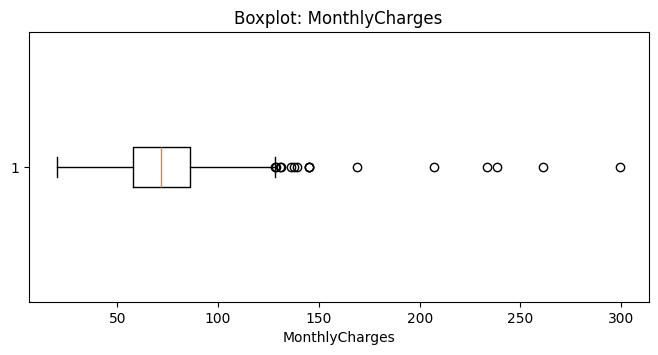

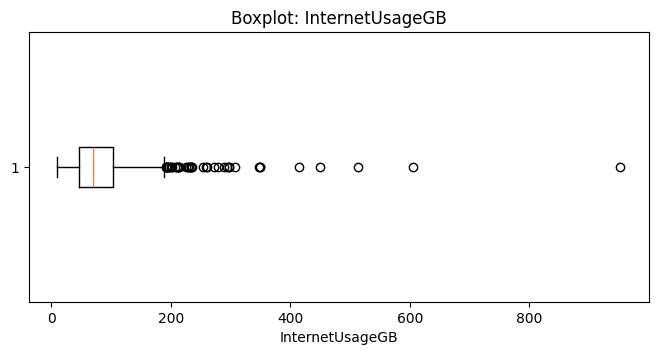

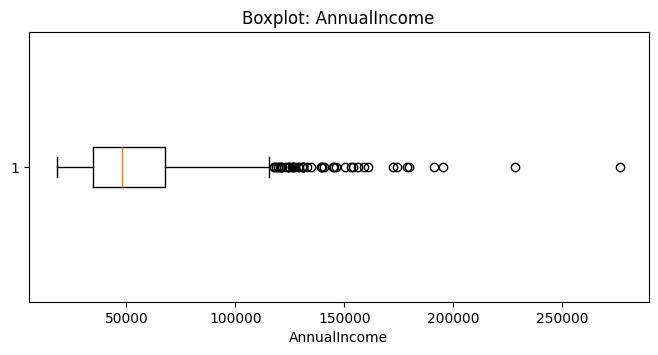

In [18]:
for col in ["MonthlyCharges", "InternetUsageGB", "AnnualIncome"]:
    plt.figure(figsize=(8, 3.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

In [19]:
def iqr_outlier_summary(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(mask.sum())
    }

for col in ["MonthlyCharges", "InternetUsageGB", "AnnualIncome"]:
    print(col, iqr_outlier_summary(df[col]))

MonthlyCharges {'Q1': np.float64(57.89), 'Q3': np.float64(86.0525), 'IQR': np.float64(28.162499999999994), 'Lower_Bound': np.float64(15.646250000000009), 'Upper_Bound': np.float64(128.29625), 'Outlier_Count': 16}
InternetUsageGB {'Q1': np.float64(47.082499999999996), 'Q3': np.float64(104.1075), 'IQR': np.float64(57.025000000000006), 'Lower_Bound': np.float64(-38.45500000000001), 'Upper_Bound': np.float64(189.645), 'Outlier_Count': 43}
AnnualIncome {'Q1': np.float64(34595.75), 'Q3': np.float64(67722.065), 'IQR': np.float64(33126.315), 'Lower_Bound': np.float64(-15093.722500000003), 'Upper_Bound': np.float64(117411.5375), 'Outlier_Count': 46}


In [20]:
col = "MonthlyCharges"

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

monthly_outliers = df[(df[col] < lower) | (df[col] > upper)]
display(monthly_outliers[["CustomerID", col, "Churn"]].head(20))

,CustomerID,MonthlyCharges,Churn
165,CUST100165,206.922069,0
171,CUST100171,145.000000,1
173,CUST100173,233.472352,0
228,CUST100228,144.870000,0
261,CUST100261,238.275503,0
343,CUST100343,136.280000,0
369,CUST100369,128.440000,1
483,CUST100483,145.000000,0
554,CUST100554,137.530000,0
626,CUST100626,130.730000,0


## 9.1 Capping Instead of Deleting

We cap at the 1st and 99th percentiles as one demonstration. This is not universally correct; treatment depends on domain meaning.

In [21]:
p01 = df["MonthlyCharges"].quantile(0.01)
p99 = df["MonthlyCharges"].quantile(0.99)

df["MonthlyCharges_Capped"] = df["MonthlyCharges"].clip(p01, p99)

display(df[["MonthlyCharges", "MonthlyCharges_Capped"]].describe())

,MonthlyCharges,MonthlyCharges_Capped
count,1176.000000,1176.000000
mean,72.761644,72.195458
std,24.844344,22.065279
min,20.000000,20.000000
25%,57.890000,57.890000
50%,71.850000,71.850000
75%,86.052500,86.052500
max,299.558842,132.490173


# 10. Feature Transformation

We will demonstrate:
- log transformation,
- standardization,
- min-max scaling,
- one-hot encoding.

## 10.1 Log Transformation of a Skewed Feature

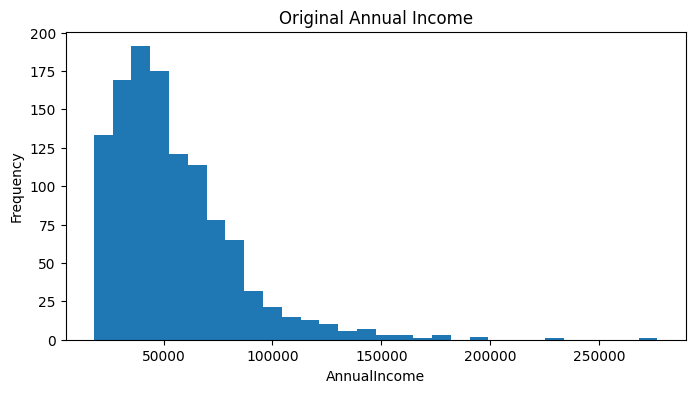

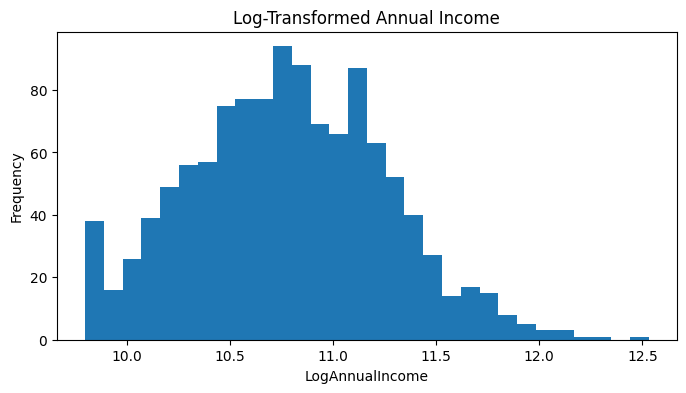

Original skewness: 1.871
Log-transformed skewness: 0.157


In [22]:
df["LogAnnualIncome"] = np.log1p(df["AnnualIncome"])

plt.figure(figsize=(8, 4))
plt.hist(df["AnnualIncome"].dropna(), bins=30)
plt.title("Original Annual Income")
plt.xlabel("AnnualIncome")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["LogAnnualIncome"].dropna(), bins=30)
plt.title("Log-Transformed Annual Income")
plt.xlabel("LogAnnualIncome")
plt.ylabel("Frequency")
plt.show()

print("Original skewness:", round(df["AnnualIncome"].skew(), 3))
print("Log-transformed skewness:", round(df["LogAnnualIncome"].skew(), 3))

## 10.2 Standardization and Min-Max Scaling

In [23]:
scale_demo = df[["Age", "MonthlyCharges"]].copy()
scale_demo = scale_demo.fillna(scale_demo.median())

std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

standardized = std_scaler.fit_transform(scale_demo)
minmaxed = mm_scaler.fit_transform(scale_demo)

standardized_df = pd.DataFrame(
    standardized,
    columns=["Age_Standardized", "MonthlyCharges_Standardized"]
)

minmax_df = pd.DataFrame(
    minmaxed,
    columns=["Age_MinMax", "MonthlyCharges_MinMax"]
)

display(pd.concat([scale_demo.head(), standardized_df.head(), minmax_df.head()], axis=1))

,Age,MonthlyCharges,Age_Standardized,MonthlyCharges_Standardized,Age_MinMax,MonthlyCharges_MinMax
0,27.0,63.58,-1.035102,-0.372731,0.157895,0.155888
1,36.0,100.15,-0.226838,1.114791,0.315789,0.286702
2,40.0,77.08,0.132391,0.176395,0.385965,0.204179
3,23.0,30.90,-1.394330,-1.702023,0.087719,0.038990
4,56.0,59.27,1.569305,-0.548045,0.666667,0.140471


## 10.3 One-Hot Encoding

In [24]:
encoded_demo = pd.get_dummies(
    df[["ContractType", "PaymentMethod"]].head(10),
    drop_first=False
)

display(encoded_demo)

,ContractType_Month-to-Month,ContractType_One Year,ContractType_Two Year,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Net Banking,PaymentMethod_UPI
0,False,True,False,False,False,True,False
1,False,True,False,True,False,False,False
2,True,False,False,False,False,False,True
3,False,True,False,True,False,False,False
4,True,False,False,False,True,False,False
5,False,True,False,False,True,False,False
6,True,False,False,False,False,False,True
7,True,False,False,False,True,False,False
8,False,False,True,False,False,False,True
9,False,True,False,False,False,True,False


# 11. Feature Selection

We compare three families:
- Filter method: SelectKBest
- Wrapper method: RFE
- Embedded method: Random Forest feature importance

In [25]:
feature_selection_cols = [
    "Age", "TenureMonths", "MonthlyCharges",
    "SupportCalls", "SatisfactionScore",
    "InternetUsageGB", "AnnualIncome"
]

X_fs = df[feature_selection_cols].copy()
X_fs = X_fs.fillna(X_fs.median())
y_fs = df["Churn"]

selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_fs, y_fs)

selectkbest_result = pd.DataFrame({
    "Feature": X_fs.columns,
    "Score": selector.scores_,
    "Selected": selector.get_support()
}).sort_values("Score", ascending=False)

display(selectkbest_result)

,Feature,Score,Selected
4,SatisfactionScore,59.301798,True
2,MonthlyCharges,18.726162,True
1,TenureMonths,16.637394,True
3,SupportCalls,4.555932,True
6,AnnualIncome,2.815012,False
5,InternetUsageGB,0.023787,False
0,Age,0.018864,False


In [26]:
rfe_model = LogisticRegression(max_iter=2000)
rfe = RFE(rfe_model, n_features_to_select=4)
rfe.fit(X_fs, y_fs)

rfe_result = pd.DataFrame({
    "Feature": X_fs.columns,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values(["Selected", "Rank"], ascending=[False, True])

display(rfe_result)

,Feature,Selected,Rank
1,TenureMonths,True,1
2,MonthlyCharges,True,1
3,SupportCalls,True,1
4,SatisfactionScore,True,1
0,Age,False,2
5,InternetUsageGB,False,3
6,AnnualIncome,False,4


,Importance
MonthlyCharges,0.202715
AnnualIncome,0.177513
InternetUsageGB,0.170998
TenureMonths,0.156789
Age,0.132379
SatisfactionScore,0.089038
SupportCalls,0.070568


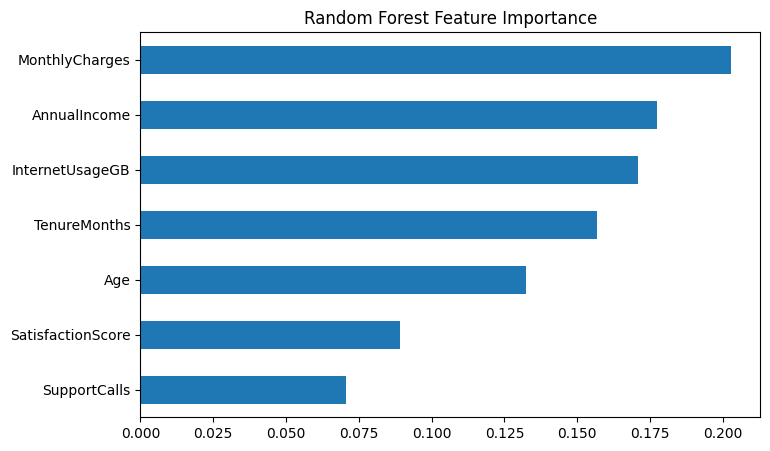

In [27]:
rf = RandomForestClassifier(
    n_estimators=250,
    random_state=42
)
rf.fit(X_fs, y_fs)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_fs.columns
).sort_values(ascending=False)

display(rf_importance.to_frame("Importance"))

rf_importance.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Random Forest Feature Importance")
plt.show()

# 12. Data Imbalance Handling

We demonstrate:
1. class distribution,
2. random oversampling,
3. class weights,
4. optional SMOTE.

In [28]:
print("Original class distribution:")
display(df["Churn"].value_counts().to_frame("Count"))

Original class distribution:


,Count
Churn,
0,1068
1,132


In [29]:
majority = df[df["Churn"] == 0]
minority = df[df["Churn"] == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

oversampled_df = pd.concat([majority, minority_upsampled])

print("After random oversampling:")
display(oversampled_df["Churn"].value_counts().to_frame("Count"))

After random oversampling:


,Count
Churn,
0,1068
1,1068


## 12.1 Important Leakage Rule

Split first. Resampling is a training-data operation.

**Correct order:**  
`Train/Test Split → Fit preprocessing on training data → Resample training data if needed → Train model → Evaluate on untouched test data`

# 13. Build a Leakage-Safe Preprocessing Pipeline

In [30]:
model_df = df.drop(columns=[
    "MonthlyCharges_Capped",
    "LogAnnualIncome"
], errors="ignore").copy()

X = model_df.drop(columns=["CustomerID", "Churn"])
y = model_df["Churn"]

numeric_features = [
    "Age", "TenureMonths", "MonthlyCharges", "TotalCharges",
    "SupportCalls", "SatisfactionScore", "InternetUsageGB", "AnnualIncome"
]

categorical_features = [
    "Gender", "ContractType", "PaymentMethod", "Region"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created.")

Preprocessor created.


# 14. Stratified Train-Test Split

`stratify=y` preserves approximately the same target-class proportion in train and test sets.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target proportion:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target proportion:")
print(y_test.value_counts(normalize=True).sort_index())

Training shape: (960, 12)
Testing shape: (240, 12)

Training target proportion:
Churn
0    0.889583
1    0.110417
Name: proportion, dtype: float64

Testing target proportion:
Churn
0    0.891667
1    0.108333
Name: proportion, dtype: float64


# 15. Baseline Logistic Regression vs Class-Weighted Logistic Regression

In [32]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)
baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

print("BASELINE MODEL")
print("Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, baseline_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, baseline_prob), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))
print("\nClassification Report:")
print(classification_report(y_test, baseline_pred, digits=4))

BASELINE MODEL
Accuracy: 0.8917
Balanced Accuracy: 0.5169
ROC-AUC: 0.7399

Confusion Matrix:
[[213   1]
 [ 25   1]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8950    0.9953    0.9425       214
           1     0.5000    0.0385    0.0714        26

    accuracy                         0.8917       240
   macro avg     0.6975    0.5169    0.5070       240
weighted avg     0.8522    0.8917    0.8481       240



In [33]:
balanced_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    ))
])

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)
balanced_prob = balanced_pipeline.predict_proba(X_test)[:, 1]

print("CLASS-WEIGHTED MODEL")
print("Accuracy:", round(accuracy_score(y_test, balanced_pred), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, balanced_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, balanced_prob), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))
print("\nClassification Report:")
print(classification_report(y_test, balanced_pred, digits=4))

CLASS-WEIGHTED MODEL
Accuracy: 0.7042
Balanced Accuracy: 0.699
ROC-AUC: 0.7126

Confusion Matrix:
[[151  63]
 [  8  18]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9497    0.7056    0.8097       214
           1     0.2222    0.6923    0.3364        26

    accuracy                         0.7042       240
   macro avg     0.5860    0.6990    0.5731       240
weighted avg     0.8709    0.7042    0.7584       240



## 15.1 Compare Models

Do not automatically select the model with the highest accuracy.

For churn detection, compare:
- recall for class 1,
- F1-score for class 1,
- balanced accuracy,
- ROC-AUC,
- business cost of false negatives and false positives.

# 16. Optional: SMOTE

This section runs only if `imbalanced-learn` is installed.

SMOTE must be applied to the **training data only**. Because our dataset contains categorical variables, a production-grade implementation should consider `SMOTENC` or an imbalanced-learn pipeline. The short demonstration below uses the already processed numerical representation.

In [34]:
try:
    from imblearn.over_sampling import SMOTE

    # Fit preprocessing ONLY on training data
    X_train_processed = preprocessor.fit_transform(X_train)

    # Convert sparse matrix to dense only for this small teaching dataset
    if hasattr(X_train_processed, "toarray"):
        X_train_processed = X_train_processed.toarray()

    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X_train_processed, y_train)

    print("Before SMOTE:")
    print(y_train.value_counts())

    print("\nAfter SMOTE:")
    print(pd.Series(y_smote).value_counts())

except ImportError:
    print(
        "imbalanced-learn is not installed. "
        "Install it with: pip install imbalanced-learn"
    )

Before SMOTE:
Churn
0    854
1    106
Name: count, dtype: int64

After SMOTE:
Churn
0    854
1    854
Name: count, dtype: int64


# 17. Final Unit-II Checklist

Before moving to a supervised-learning algorithm, ask:

- Did I understand the meaning of every feature?
- Did I inspect missing values and duplicates?
- Did I visualize distributions?
- Did I check target balance?
- Did I investigate outliers?
- Did I examine correlation and redundancy?
- Did I distinguish feature selection from feature transformation?
- Did I choose an appropriate encoding strategy?
- Did I place preprocessing inside a pipeline?
- Did I protect the test set from leakage?

# 18. Student Lab Tasks

Complete the following without copying the solution directly:

1. Find the three columns with the highest missing-value percentages.
2. Compare mean and median for `AnnualIncome`.
3. Draw a violin plot of `MonthlyCharges` against `Churn`.
4. Calculate churn percentage for every `Region`.
5. Find the strongest positive Pearson correlation excluding self-correlation.
6. Compare Pearson and Spearman correlation for `InternetUsageGB` and `AnnualIncome`.
7. Detect `InternetUsageGB` outliers using IQR.
8. Create `LogInternetUsageGB`.
9. Compare skewness before and after transformation.
10. Use `SelectKBest` to select the best five numerical predictors.
11. Build a preprocessing pipeline from scratch.
12. Compare Logistic Regression with and without class weighting.
13. Explain which metric you would prioritize if missing a churner is more costly than contacting a non-churner.
14. Explain why `CustomerID` should normally be excluded from the model.
15. Write three examples of possible data leakage in this notebook.